<a href="https://colab.research.google.com/github/Yukkitsune/TBank-Analytics/blob/main/Machine%20learning/Feature_importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Используйте датасет Credit Card Default Prediction (предсказание дефолта по кредитной карте), доступный по ссылке:
https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

Целевая переменная: default.payment.next.month (дефолт в следующем месяце).
Признаки: демографические данные, история платежей, сумма кредита и др.



In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
np.random.seed=42

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance
from catboost import CatBoostClassifier, Pool

In [ ]:
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
print(f"Путь к датасету: {path}")


import os
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            df = pd.read_csv(os.path.join(root, file))
            break

Путь к датасету: C:\Users\akito\.cache\kagglehub\datasets\uciml\default-of-credit-card-clients-dataset\versions\1


ID: идентификатор каждого клиента

LIMIT_BAL: Сумма предоставляемого кредита в новозеландских долларах (включает индивидуальный и семейный / дополнительный кредит

ПОЛ: Гендер (1= мужчина, 2=женщина)

ОБРАЗОВАНИЕ: (1= аспирантура, 2= университет, 3 = средняя школа, 4 = другие, 5= неизвестно, 6= неизвестно)

БРАК: Семейное положение (1 = женат, 2= холост, 3 = другие)

ВОЗРАСТ: возраст в годах

PAY_0: Статус погашения в сентябре 2005 года (-1 = оплата своевременно, 1 = задержка платежа на один месяц, 2 = задержка платежа на два месяца, ... 8 = задержка платежа на восемь месяцев, 9 = задержка платежа на девять месяцев и выше)

PAY_2: Статус погашения в августе 2005 г. (шкала такая же, как указано выше)

PAY_3: статус погашения в июле 2005 г. (шкала такая же, как указано выше)

PAY_4: Статус погашения в июне 2005 г. (шкала такая же, как указано выше)

PAY_5: статус погашения в мае 2005 г. (шкала такая же, как указано выше)

PAY_6: Статус погашения в апреле 2005 г. (шкала такая же, как указано выше)

BILL_AMT1: Сумма выписки по счету за сентябрь 2005 года (NT dollar)

BILL_AMT2: Сумма выписки по счету за август 2005 года (NT dollar)

BILL_AMT3: Сумма выписки по счету за июль 2005 года (NT dollar)

BILL_AMT4: Сумма выписки по счету за июнь 2005 года (NT dollar)

BILL_AMT5: Сумма выписки по счету за май 2005 года (NT dollar)

BILL_AMT6: Сумма выписки по счету в апреле 2005 года (NT dollar)

PAY_AMT1: Сумма предыдущего платежа в сентябре 2005 года (NT dollar)

PAY_AMT2: Сумма предыдущего платежа в августе 2005 года (NT dollar)

PAY_AMT3: Сумма предыдущего платежа в июле 2005 года (NT dollar)

PAY_AMT4: Сумма предыдущего платежа в июне 2005 года (NT dollar)

PAY_AMT5: Сумма предыдущего платежа в мае 2005 года (NT dollar)

PAY_AMT6: Сумма предыдущего платежа в апреле 2005 года (NT dollar)

default.payment.next.month: Платеж по умолчанию (1 = да, 0 = нет)


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [ ]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


# Задача 1. Подготовка данных и базовое моделирование (1 балла)
- Загрузите датасет, разделите на обучающую и тестовую выборки (80/20).

- Обучите модель CatBoostClassifier с параметрами по умолчанию.

- Оцените качество модели с помощью ROC-AUC на тесте.

## Загрузите датасет, разделите на обучающую и тестовую выборки (80/20).

In [ ]:
X = df.drop(columns=['default.payment.next.month','ID'], axis=1) # Кроме таргета удалим и ID, чтобы не путать модель
y = df['default.payment.next.month']

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_val: {X_val.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_val: {y_val.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (18000, 23)
Shape of X_val: (6000, 23)
Shape of X_test: (6000, 23)
Shape of y_train: (18000,)
Shape of y_val: (6000,)
Shape of y_test: (6000,)


In [ ]:
X_train.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
10574,20000.0,2,3,1,51,0,0,0,-2,-2,...,0.0,0.0,0.0,0.0,2000.0,0.0,0.0,0.0,0.0,0.0
11330,300000.0,1,2,2,31,0,0,0,0,0,...,298378.0,131103.0,128742.0,124882.0,12507.0,15056.0,5027.0,5007.0,5063.0,3039.0
7127,500000.0,1,2,2,40,-1,-1,-1,-1,0,...,48017.0,49403.0,40018.0,54109.0,99159.0,48276.0,49450.0,201.0,54379.0,9905.0
25150,70000.0,2,2,1,46,0,0,0,0,0,...,71318.0,59665.0,29510.0,26738.0,2600.0,3700.0,2600.0,1200.0,1200.0,1000.0
6000,50000.0,1,2,1,33,0,0,0,0,0,...,6879.0,6753.0,5440.0,5440.0,2000.0,1284.0,264.0,109.0,390.0,0.0


In [ ]:
y_train.value_counts()

default.payment.next.month
0    14018
1     3982
Name: count, dtype: int64

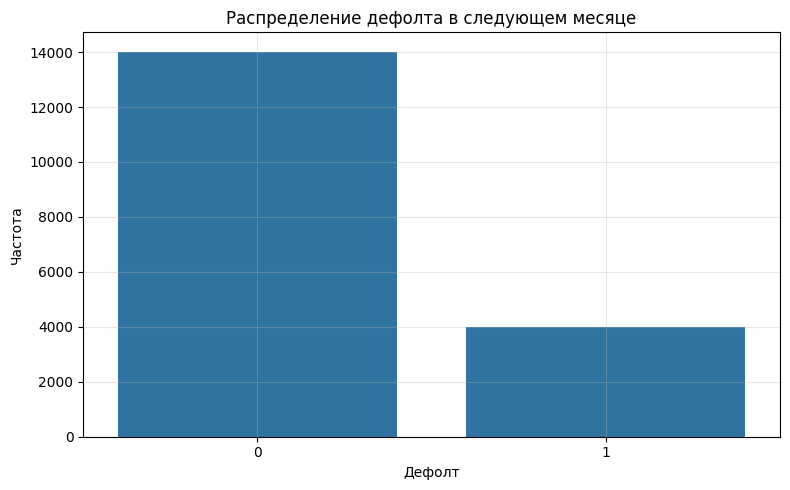

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x=y_train)
plt.title('Распределение дефолта в следующем месяце')
plt.xlabel('Дефолт')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
def plot_all_features(df: pd.DataFrame) -> None:
    num_cols = df.shape[1]
    num_rows = (num_cols + 2) // 3
    plt.figure(figsize=(18, 5*num_rows))
    for i, column in enumerate(df.columns):
        plt.subplot(num_rows, 3, i + 1)
        if column in df.select_dtypes(include=np.number):
            sns.histplot(df[column], kde=True)
        else:
            sns.barplot(x=df[column].value_counts().index, y=df[column].value_counts().values)
            plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.xlabel(column)
        plt.ylabel('Частота')
        plt.title(f'Распределение {column}')
        plt.tight_layout()
    plt.show()

Видим, что в датасете все категориальные фичи уже приведены к числовому виду

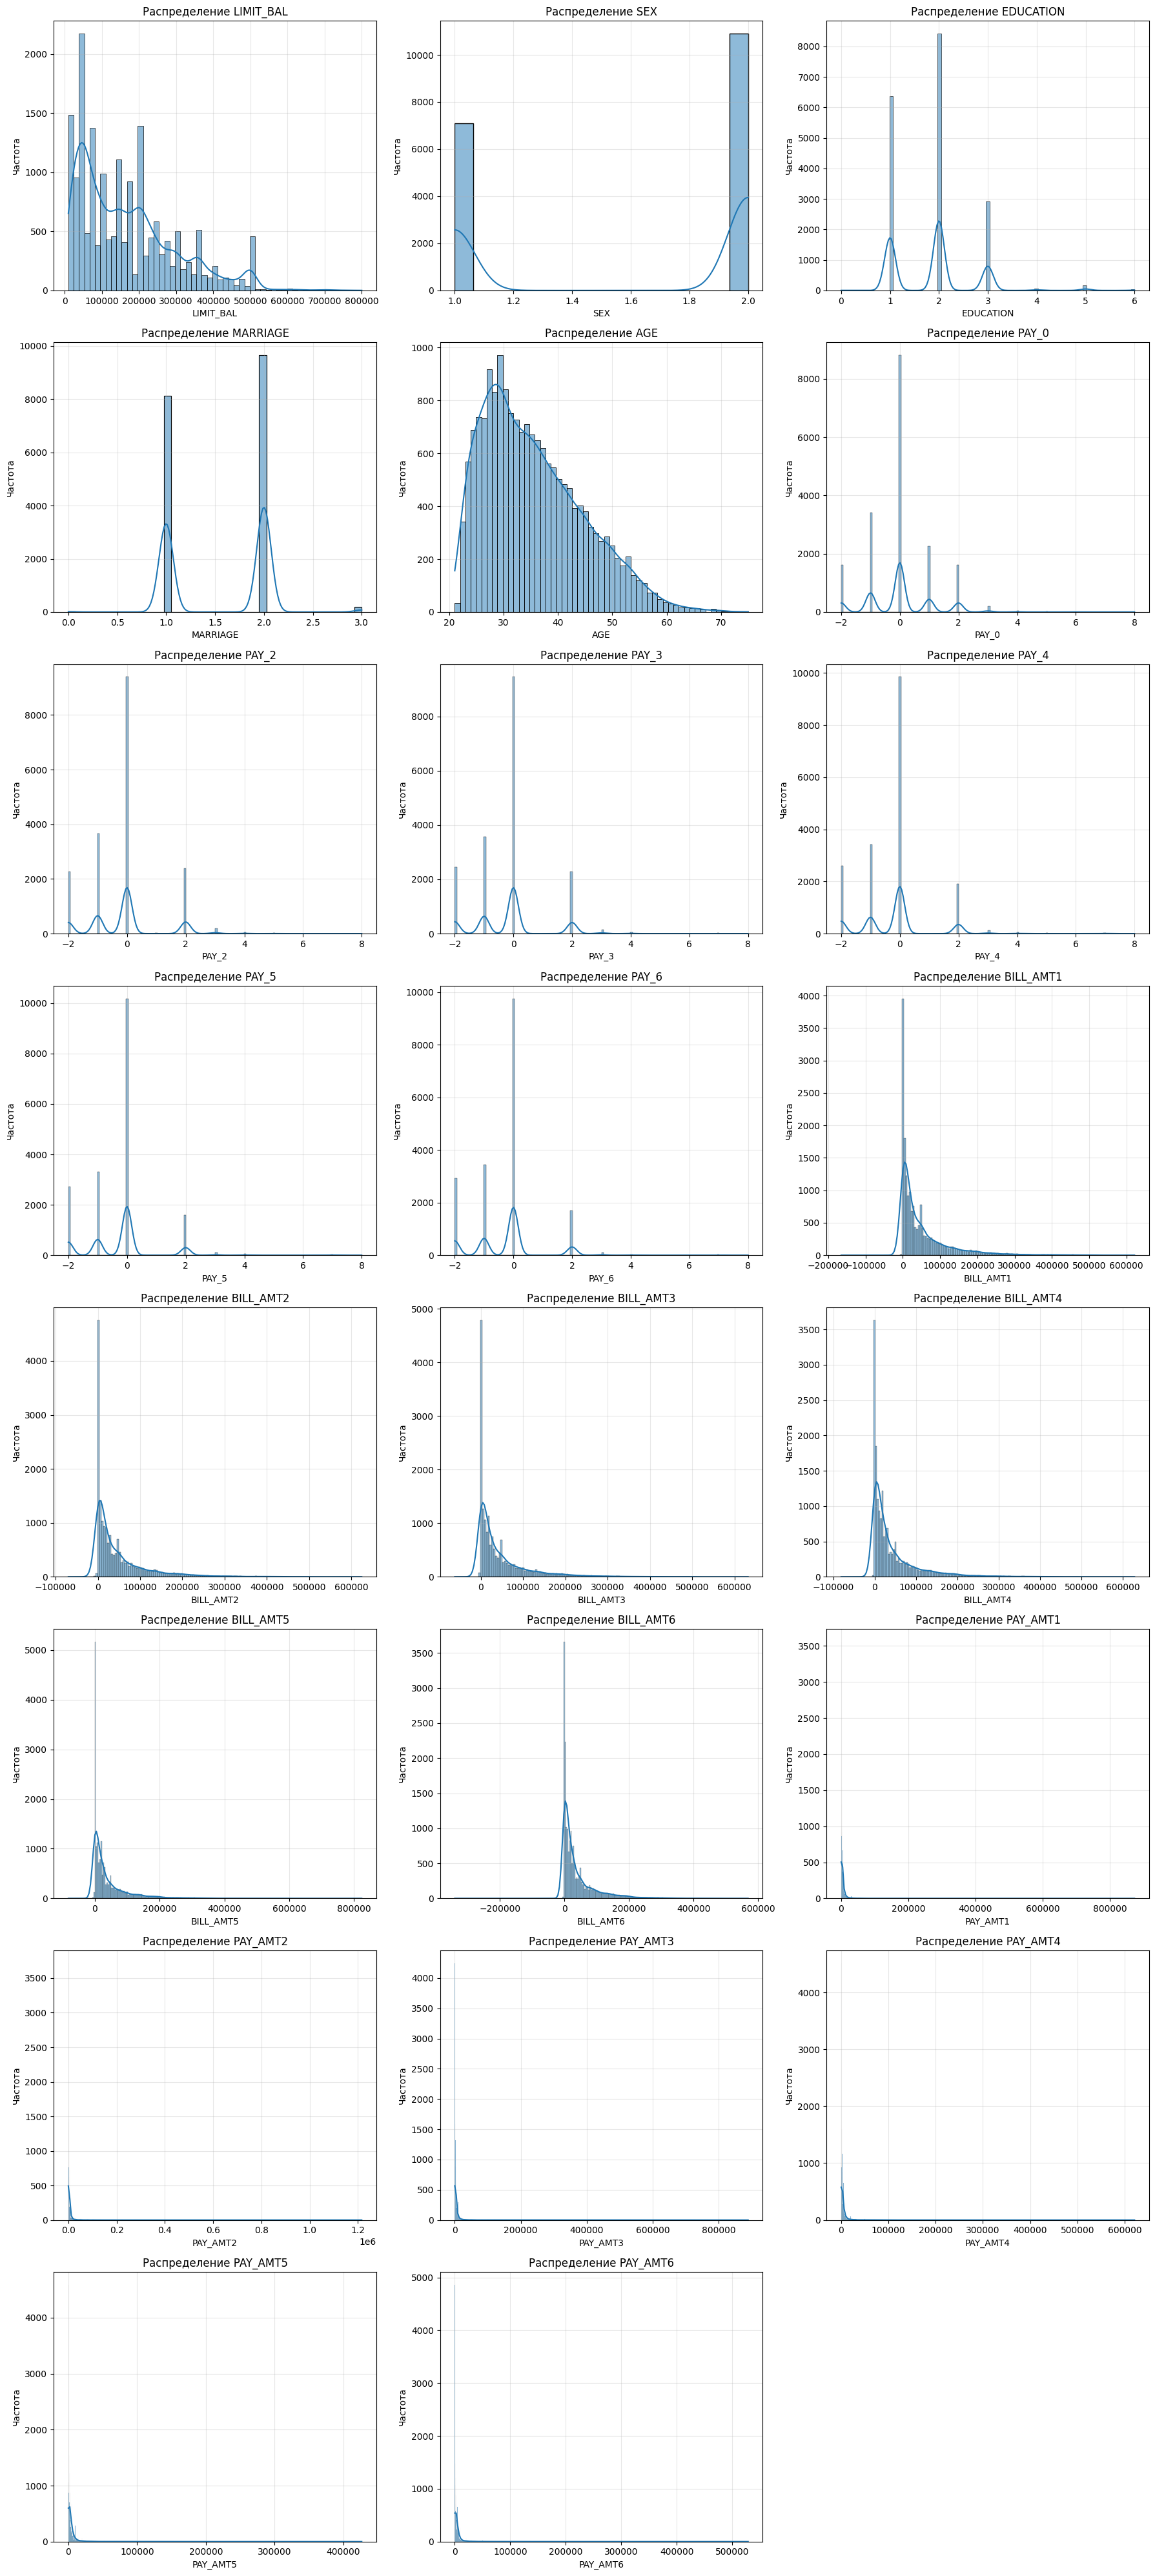

In [ ]:
plot_all_features(X_train)

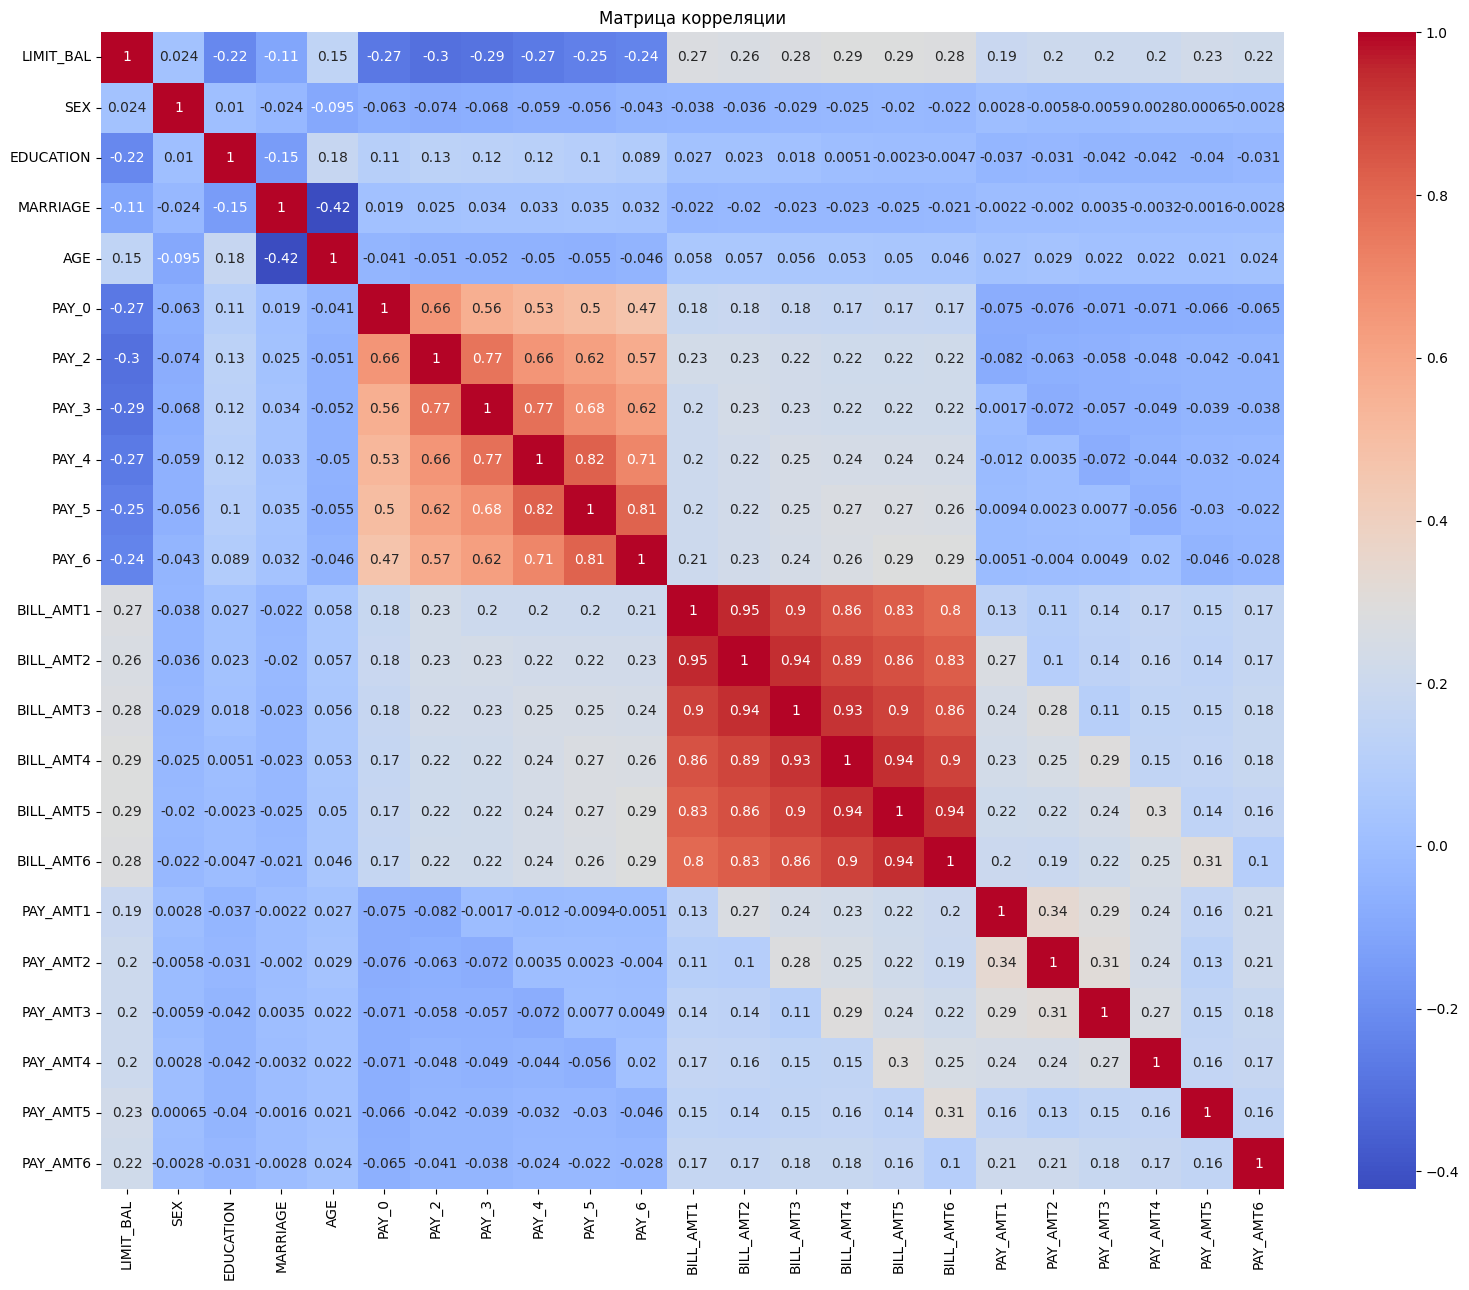

In [ ]:
corr_matrix = np.corrcoef(X_train, rowvar=False)
plt.figure(figsize=(16,13))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            xticklabels=X_train.columns,
            yticklabels=X_train.columns
            )
plt.title("Матрица корреляции")
plt.tight_layout()
plt.show()

## Обучите модель CatBoostClassifier с параметрами по умолчанию.

In [ ]:
def get_catboost_model(X_train: pd.DataFrame, y_train: pd.DataFrame,
                       X_val: pd.DataFrame, y_val: pd.DataFrame,
                       ) -> tuple:
    cb_cls = CatBoostClassifier(
    random_seed=42,
    eval_metric='AUC',
    early_stopping_rounds=200,
    verbose=0
    )
    cb_cls.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val)
    )

    return cb_cls

In [ ]:
def get_auc(model, X_test: pd.DataFrame, y_test: pd.DataFrame) -> float:
    y_pred = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred)
    return roc_auc

In [ ]:
def print_diff(current: dict, all_models: dict) -> None:
    current_name = list(current.keys())[0]
    current_roc = current[current_name]
    print(f'{"=" * 40}\n')
    print(f'ROC AUC Score {current_name} -> {current_roc:.4f}')
    print(f'\n{current_name} roc auc difference with other models:')
    for name, acc in all_models.items():
        diff = current_roc - acc
        rel_diff = (diff / acc) * 100
        print(f'{name} -> {diff:.4f} ({rel_diff:+.4f}%)')
    print(f'{"=" * 40}\n')
    all_models[current_name] = current_roc

In [ ]:
cb_cls = get_catboost_model(
    X_train, y_train,
    X_val, y_val
)

## Оцените качество модели с помощью ROC-AUC на тесте.

In [ ]:
def plot_roc(score: list, y_test: pd.DataFrame) -> None:
    fpr, tpr, thresholds = roc_curve(y_test, score)
    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, label='ROC Curve')
    plt.plot([0, 1], [0, 1], label='Random model', linestyle='--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC Curve')
    plt.legend()
    plt.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
roc_auc_original = get_auc(cb_cls, X_test, y_test)
print(f'ROC AUC Score Original -> {roc_auc_original:.4f}')

ROC AUC Score Original -> 0.7751


In [ ]:
all_models = {'Original' : roc_auc_original}

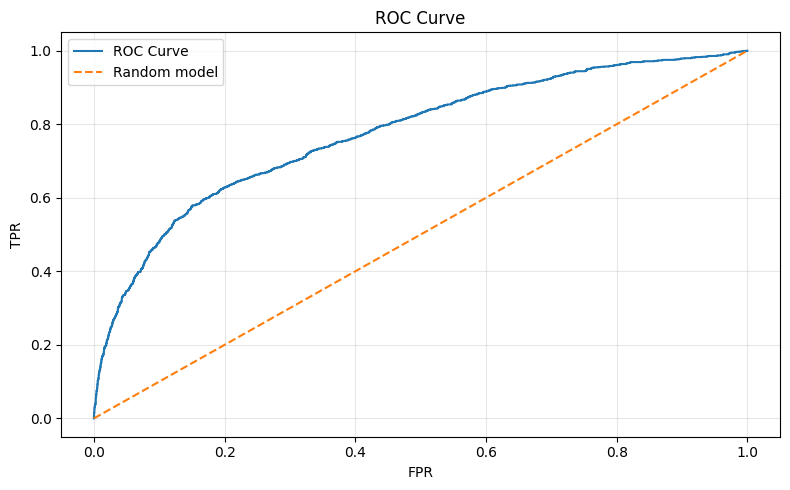

In [ ]:
plot_roc(cb_cls.predict_proba(X_test)[:, 1], y_test)

# Задача 2. Оценка важности признаков (2 балла)
- Встроенная важность CatBoost (PredictionValuesChange) используйте get_feature_importance() для получения важности признаков, основанной на изменении предсказаний.

- Permutation Importance,используйте sklearn.inspection.permutation_importance. Постройте боксплот важности признаков.

- SHAP-анализ, используйте SHAP-значения для тестовой выборки.Постройте summary plot (bar и dot). Выберите одно наблюдение и объясните его предсказание с помощью shap.force_plot

Важно! Вычисляйте важность на обучающей или валидационной выборке, но не на тестовой. Тестовая выборка используется только для финальной оценки модели.

## Встроенная важность CatBoost (PredictionValuesChange) используйте get_feature_importance() для получения важности признаков, основанной на изменении предсказаний.

In [ ]:
def get_feature_importance_df(X_val: pd.DataFrame, model):
    importance = model.get_feature_importance(
        data=Pool(X_val)
    )
    feature_df = pd.DataFrame({
        'Feature': X_val.columns,
        'Importance': importance
    })
    return feature_df.sort_values('Importance', ascending=False).reset_index(drop=True)

In [ ]:
embedded_importance = get_feature_importance_df(X_val, cb_cls)
embedded_importance

,Feature,Importance
0,PAY_0,12.308205
1,LIMIT_BAL,8.659444
2,BILL_AMT1,7.930203
3,AGE,5.763112
4,PAY_AMT3,5.228633
5,PAY_AMT4,5.196959
6,PAY_AMT2,5.048266
7,PAY_AMT6,5.043130
8,PAY_AMT1,5.041493
9,BILL_AMT2,4.400452


## Permutation Importance,используйте sklearn.inspection.permutation_importance. Постройте боксплот важности признаков.

Чем сильнее падает AUC при перемешивании признаков, тем он важнее для модели

In [ ]:
def plot_boxplot_importance(perm_importance: list, df: pd.DataFrame) -> None:
    names = df.columns.tolist()
    importances = perm_importance.importances
    sorted_idx = (importances
                  .mean(axis=1)
                  .argsort()
                  )
    plt.figure(figsize=(10, 8))
    plt.boxplot(
        [importances[i] for i in sorted_idx],
        labels=[names[i] for i in sorted_idx],
        vert=False
    )
    plt.title('Boxplot Permutation Importance')
    plt.xlabel('Снижение AUC')
    plt.ylabel('Фичи')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


C:\Users\akito\AppData\Local\Temp\ipykernel_21956\3143897229.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


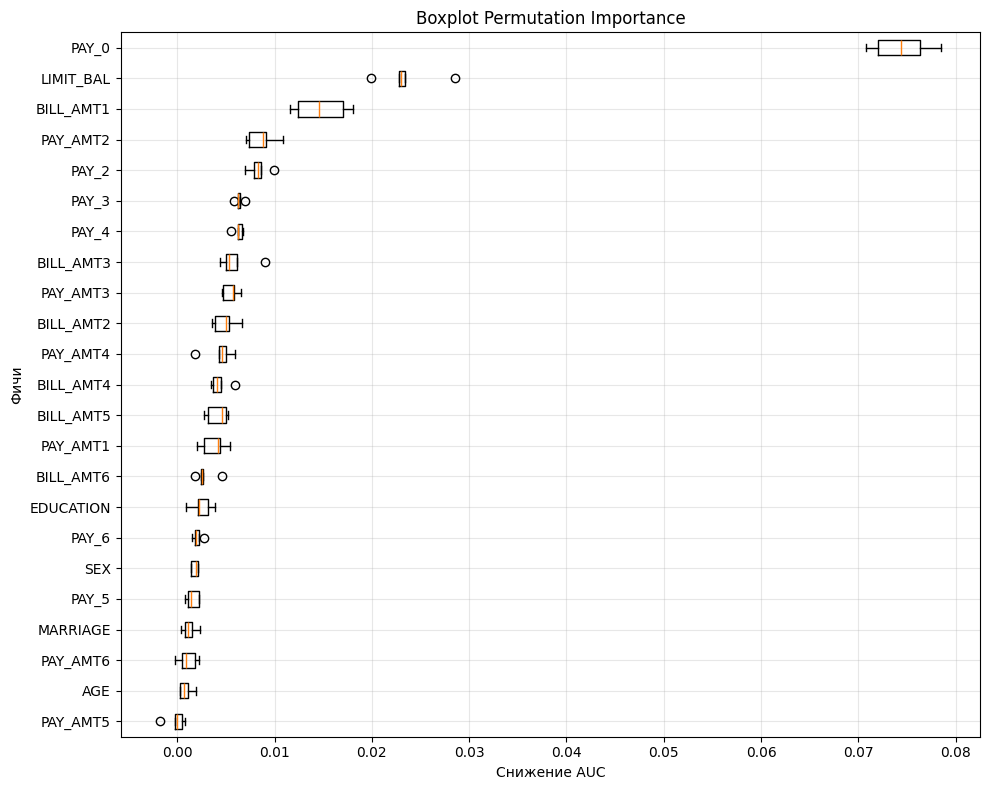

In [ ]:
perm_importance = permutation_importance(
    cb_cls,
    X_val,
    y_val,
    scoring='roc_auc',
    random_state=42
)
plot_boxplot_importance(perm_importance, X_val)

По виду коробок можно сказать, что в данных практически нет выбросов

## SHAP-анализ, используйте SHAP-значения для тестовой выборки.Постройте summary plot (bar и dot). Выберите одно наблюдение и объясните его предсказание с помощью shap.force_plot

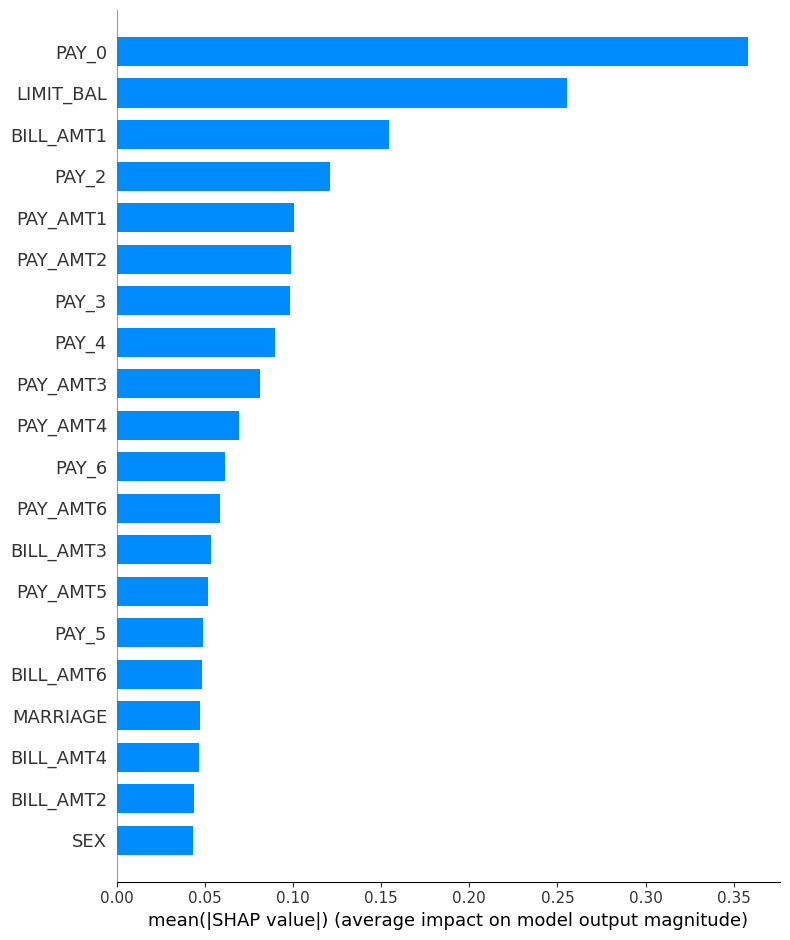

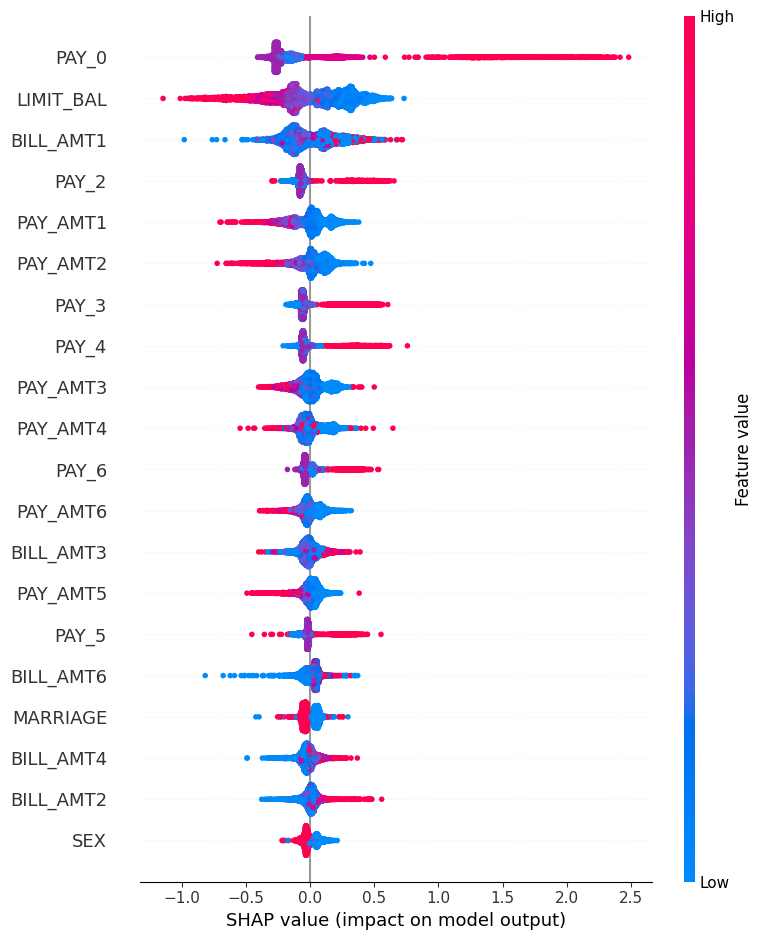

In [ ]:
explainer = shap.TreeExplainer(cb_cls)
shap_values = explainer(X_test).values
shap.initjs()
shap.summary_plot(shap_values, X_test, plot_type='bar')
shap.summary_plot(shap_values, X_test, plot_type='dot')
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])


По Force plot видим, что такие признаки как PAY_AMT2, LIMIT_BAL повышают риск дефолта у клиента в следующем месяце, а PAY_AMT1, PAY_0 и остальные синие признаки наоборот её снижают - клиент вовремя оплачивает все счета, но в то же время имеет достаточно низкий кредитный лимит. В итоге синие имеют больший эффект, из-за чего финальное предсказание (-2,14) дает низкую вероятность дефолта

Среднее предсказание для всех клиентов тоже показывает низкую вероятность дефолта, что подтверждается лидерством класса 0 в таргете

# Задача 3. Выводы (1 балла)
- Сравните топ-5 важных признаков по каждому методу.

- Найдите признаки, которые важны во всех методах;важны только в одном методе; имеют отрицательную важность в Permutation Importance.

- Объясните, почему методы могут давать разные результаты.

## Сравните топ-5 важных признаков по каждому методу.

In [ ]:
def show_top_features(model_name: str, importance_df: pd.DataFrame, top_n: int = 5) -> None:
    top_features = importance_df.head(top_n)
    sns.barplot(x=top_features['Importance'], y=top_features['Feature'])
    plt.grid(True, alpha=0.3)
    plt.title(f'Топ {top_n} признаков модели {model_name}')
    plt.xlabel('Важность')
    plt.ylabel('Признак')

In [ ]:
perm_df = pd.DataFrame({
    'Feature': X_val.columns,
    'Importance': perm_importance.importances_mean
}).sort_values('Importance', ascending=False)
shap_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': np.mean(np.abs(shap_values), axis=0)
}).sort_values('Importance', ascending=False)

importance_dict = {
    'Embedded': embedded_importance,
    'Permutation': perm_df,
    'SHAP': shap_df
}

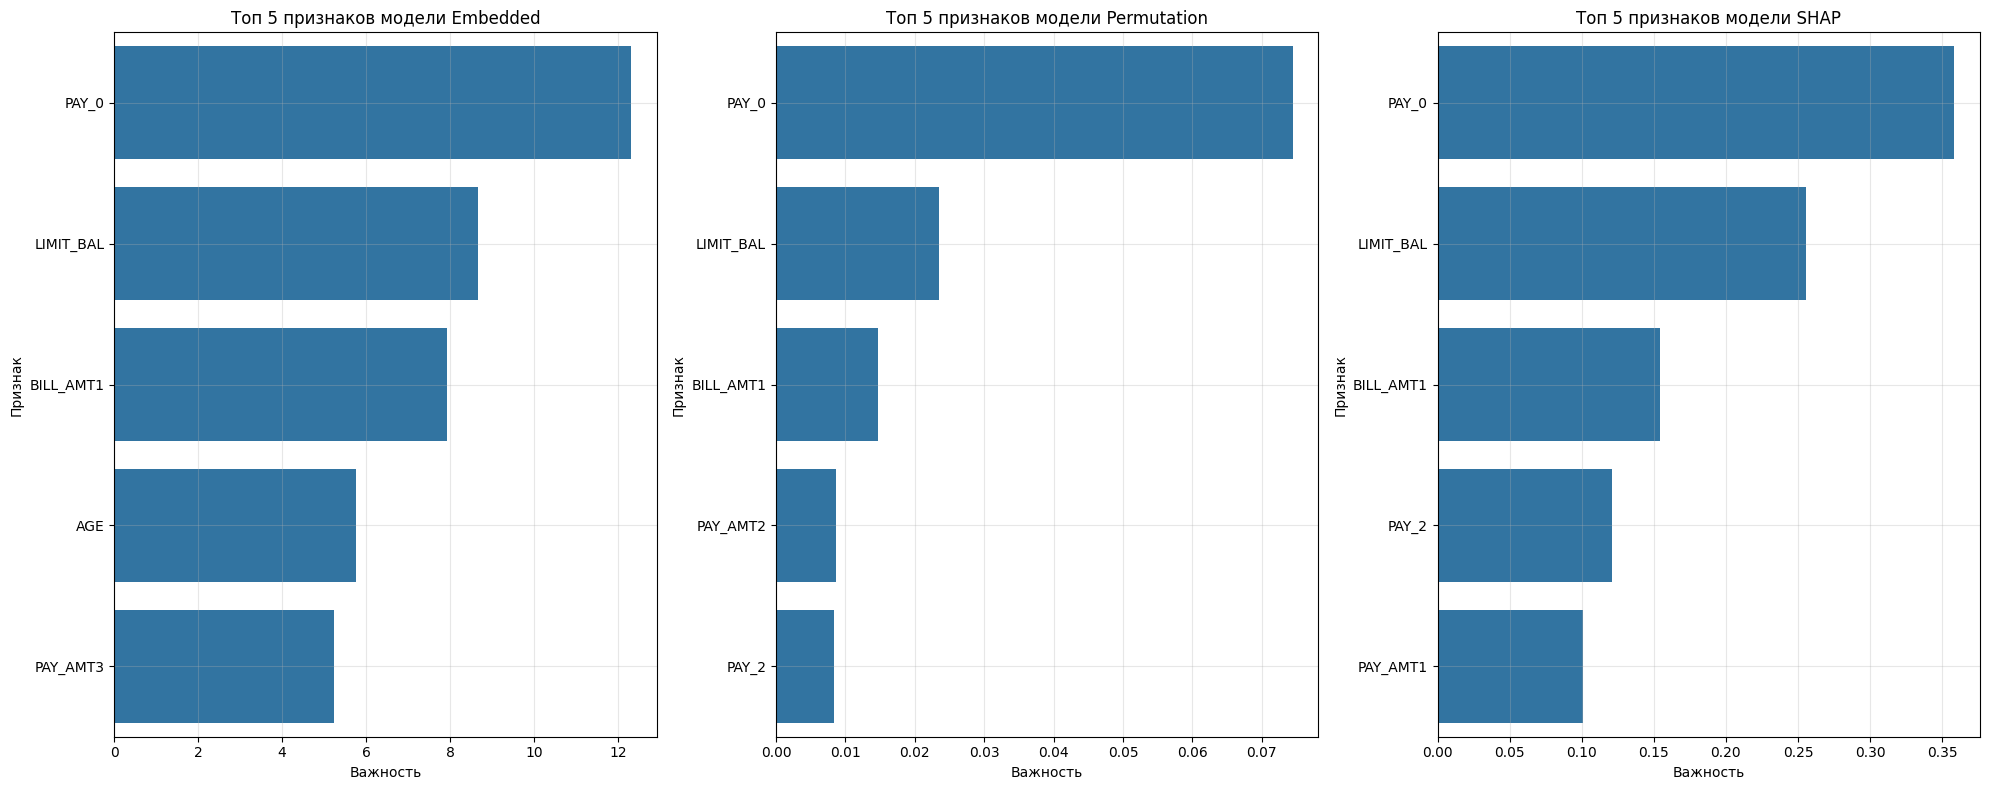

In [ ]:
plt.figure(figsize=(20, 8))
for i, method in enumerate(list(importance_dict.keys())):
    plt.subplot(1, 3, i + 1)
    show_top_features(method, importance_dict[method])
plt.tight_layout()
plt.show()

Все 3 метода имеют практически одинаковые признаки в топ 5 по важности.

В каждом из способов лидируют 3 одинаковых признака -> PAY_0 - статус погашения в сентябре, LIMIT_BAL - кредитный лимит, BILL_AMT1 - сумма выписки на текущий месяц, что согласуется с логикой.

PAY_AMTX присутствуют в каждом из способов, что так же подтверждает их важность.

В то же время в Embedded есть уникальный признак - модель обращает внимание на возраст

## Найдите признаки, которые важны во всех методах;важны только в одном методе; имеют отрицательную важность в Permutation Importance.

Для нахождения общих признаков возьмем топ 10 по важности из каждого способа

In [ ]:
top_n = 10
embedded_features = set(embedded_importance['Feature'].head(top_n))
perm_features = set(perm_df['Feature'].head(top_n))
shap_features = set(shap_df['Feature'].head(top_n))

general_features = embedded_features & perm_features & shap_features

only_embedded = embedded_features - perm_features - shap_features
only_perm = perm_features -  embedded_features - shap_features
only_shap = shap_features - embedded_features - perm_features

neg_perm = set(perm_df[perm_df['Importance'] < 0]['Feature'])

print(f'Важные во всех методах признаки -> {general_features}')
print(f'Важные в catboost feature importance признаки -> {only_embedded}')
print(f'Важные только в перестановочном методе признаки -> {only_perm}')
print(f'Важные только в SHAP признаки -> {only_shap}')
print(f'Признаки с негативной важностью в перестановочном методе -> {neg_perm}')

Важные во всех методах признаки -> {'LIMIT_BAL', 'PAY_AMT2', 'PAY_AMT3', 'BILL_AMT1', 'PAY_0'}
Важные в catboost feature importance признаки -> {'PAY_AMT6', 'AGE'}
Важные только в перестановочном методе признаки -> {'BILL_AMT3'}
Важные только в SHAP признаки -> set()
Признаки с негативной важностью в перестановочном методе -> {'PAY_AMT5'}


Из пересечения методов можем понять, что наиболее важными для модели являются суммы платежей за промежуток в 3 месяца, кредитный лимит, а так же статус платежа в текущем месяце

Негативно на предсказание модели влияет платеж, который был совершен за 5 месяцев до исследования - слишком старые данные

## Объясните, почему методы могут давать разные результаты.

Отличия в методах действительно есть - проявляются они из-за особенностей метода определения важности. Встроенный в кетбуст определитель ориентируется по частоте признака в деревьях решений - так как другие способы не обращают внимания на возраст, он мог появиться здесь из-за шума. Перестановки помогают понять, что плохо влияет на модель благодаря, собственно, перестановкам, а SHAP рассматривает, как признак влияет на конкретные предсказания для каждого клиента

# Задача 4. Отбор признаков (2 балла)

- Определите порог важности (например, важность случайного признака) и удалите менее важные признаки.

- Обучите модель на сокращённом наборе признаков и сравните ROC-AUC с исходной моделью.

- Можно ли сократить количество признаков без потери качества?

## Определите порог важности (например, важность случайного признака) и удалите менее важные признаки.

In [ ]:
def add_random_noise(df: pd.DataFrame, quantity: int = 1) -> pd.DataFrame:
    df_noise = df.copy()
    for i in range(quantity):
        df_noise[f'noise_{i}'] = np.random.randn(len(df))
    return df_noise

In [ ]:
X_train_noise = add_random_noise(X_train)
X_val_noise = add_random_noise(X_val)

cb_cls_noise = get_catboost_model(
    X_train_noise, y_train,
    X_val_noise, y_val
)
noise_imp = get_feature_importance_df(X_val_noise, cb_cls_noise)

noise_val = noise_imp[noise_imp['Feature'] == 'noise_0']['Importance'].values[0]
features_to_drop = noise_imp[noise_imp['Importance'] < noise_val]['Feature'].tolist()

X_train_threshold = X_train.drop(columns=features_to_drop)
X_val_threshold = X_val.drop(columns=features_to_drop)
X_test_threshold = X_test.drop(columns=features_to_drop)

print(f'Удалено {len(features_to_drop)} из {len(X_train.columns.tolist())} признаков')

Удалено 20 из 23 признаков


## Обучите модель на сокращённом наборе признаков и сравните ROC-AUC с исходной моделью.

In [ ]:
cb_cls_threshold = get_catboost_model(
    X_train_threshold, y_train,
    X_val_threshold, y_val
)
roc_auc_threshold = get_auc(cb_cls_threshold, X_test_threshold, y_test)
print_diff({'Noise Threshold': roc_auc_threshold}, all_models)


ROC AUC Score Noise Threshold -> 0.7552

Noise Threshold roc auc difference with other models:
Original -> -0.0199 (-2.5694%)



## Можно ли сократить количество признаков без потери качества?

При выборе случайного признака в качестве порога получили для него слишком высокую важность, из-за чего было удалено 20 из 23 признаков - 86% ,- и качество модели по ROC-AUC упало на 2.5%. Этот показатель может быть достаточно серьезным для бизнеса, следовательно таким образом отбирать признаки нельзя. Возможно, получится сократить количество признаков без потери качества, если убирать только негативно влияющие на модель качества.

In [ ]:
X_train_wt_neg = X_train.drop(columns=list(neg_perm))
X_val_wt_neg = X_val.drop(columns=list(neg_perm))
X_test_wt_neg = X_test.drop(columns=list(neg_perm))

cb_cls_wt_neg = get_catboost_model(
    X_train_wt_neg, y_train,
    X_val_wt_neg, y_val
)
roc_auc_wt_neg = get_auc(cb_cls_wt_neg, X_test_wt_neg, y_test)
print_diff({'Without negative features': roc_auc_wt_neg}, all_models)


ROC AUC Score Without negative features -> 0.7775

Without negative features roc auc difference with other models:
Original -> 0.0025 (+0.3182%)
Noise Threshold -> 0.0224 (+2.9638%)



Да, можем сократить количество признаков без потери качества модели, а может даже и улучшить её, как в нашем случае, если удалить негативно влияющие признаки. Кроме того, можем пожертвовать малым качеством, если уберем наименее влияющие фичи

# Задача 5. Анализ с добавленными случайными признаками (4 балла)

- Добавьте 10 случайных нормально распределенных признаков в датасет.

- Выполните оценку важности признаков (как в задаче 2) и проанализируйте, как методы ранжируют случайные признаки.

- Выполните отбор признаков с разными порогами 0%, 25%, 50%, 75% наименее важных признаков (удаляйте).

- Для каждого порога обучите модель и оцените ROC-AUC на тесте.

- Постройте график зависимости ROC-AUC от количества удаленных признаков.

- Проанализируйте, как изменяется качество модели при удалении разных долей признаков.


## Добавьте 10 случайных нормально распределенных признаков в датасет.

In [ ]:
X_train_10_noise = add_random_noise(X_train, 10)
X_val_10_noise = add_random_noise(X_val, 10)
X_test_10_noise = add_random_noise(X_test, 10)

## Выполните оценку важности признаков (как в задаче 2) и проанализируйте, как методы ранжируют случайные признаки.

In [ ]:
cb_cls_10_noise = get_catboost_model(
    X_train_10_noise, y_train,
    X_val_10_noise, y_val
)
perm_imp_10_noise = permutation_importance(
    cb_cls_10_noise,
    X_val_10_noise,
    y_val,
    scoring='roc_auc',
    random_state=42
)
explainer = shap.TreeExplainer(cb_cls_10_noise)
shap_values = explainer(X_test_10_noise).values

embedded_10_noise = get_feature_importance_df(X_val_10_noise, cb_cls_10_noise)
embedded_10_noise.head(10)

,Feature,Importance
0,PAY_0,18.950906
1,LIMIT_BAL,7.377843
2,BILL_AMT1,5.446171
3,PAY_2,4.528648
4,PAY_AMT3,3.732652
5,PAY_AMT2,3.708296
6,PAY_3,3.645452
7,PAY_AMT1,2.781918
8,PAY_5,2.662155
9,noise_0,2.475396


C:\Users\akito\AppData\Local\Temp\ipykernel_21956\3143897229.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


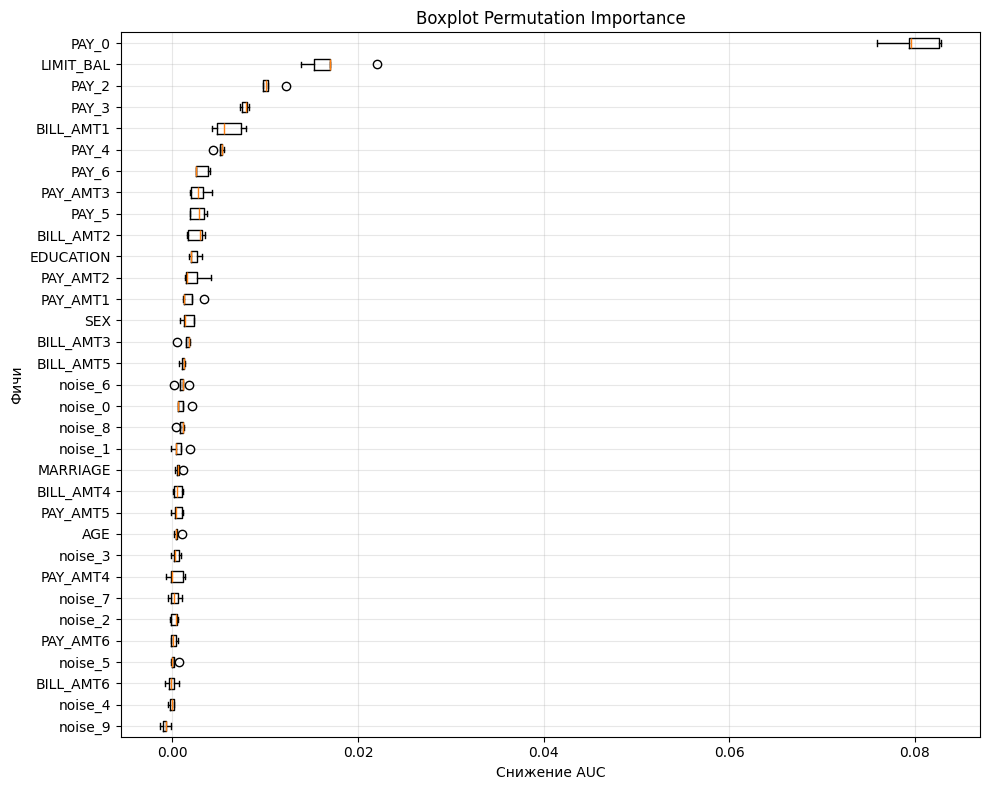

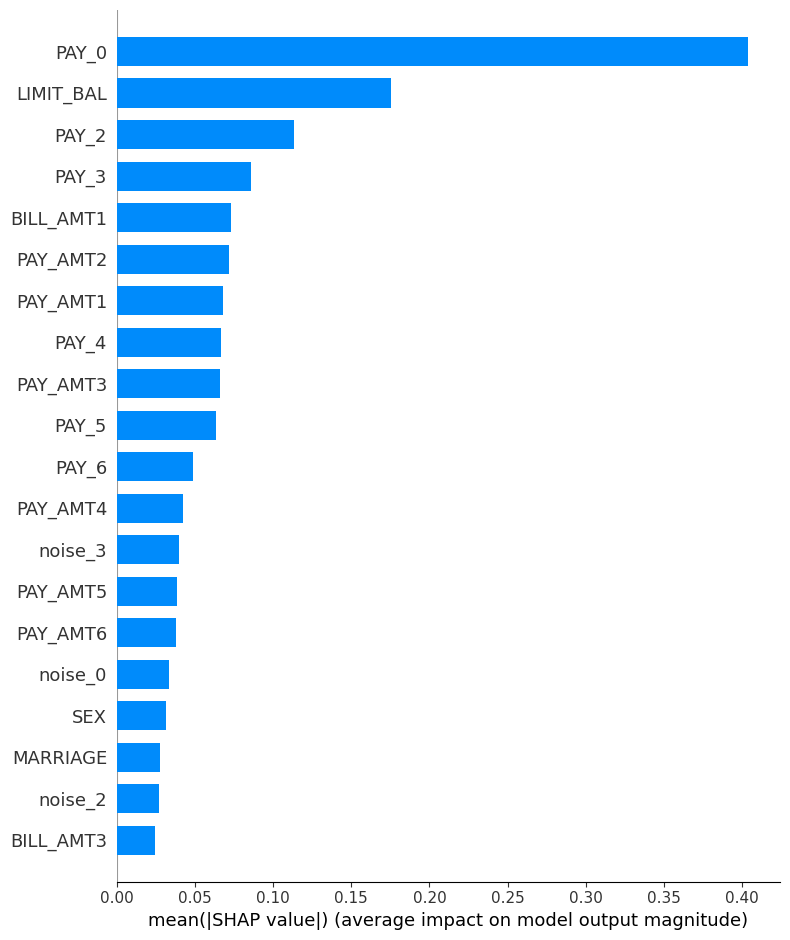

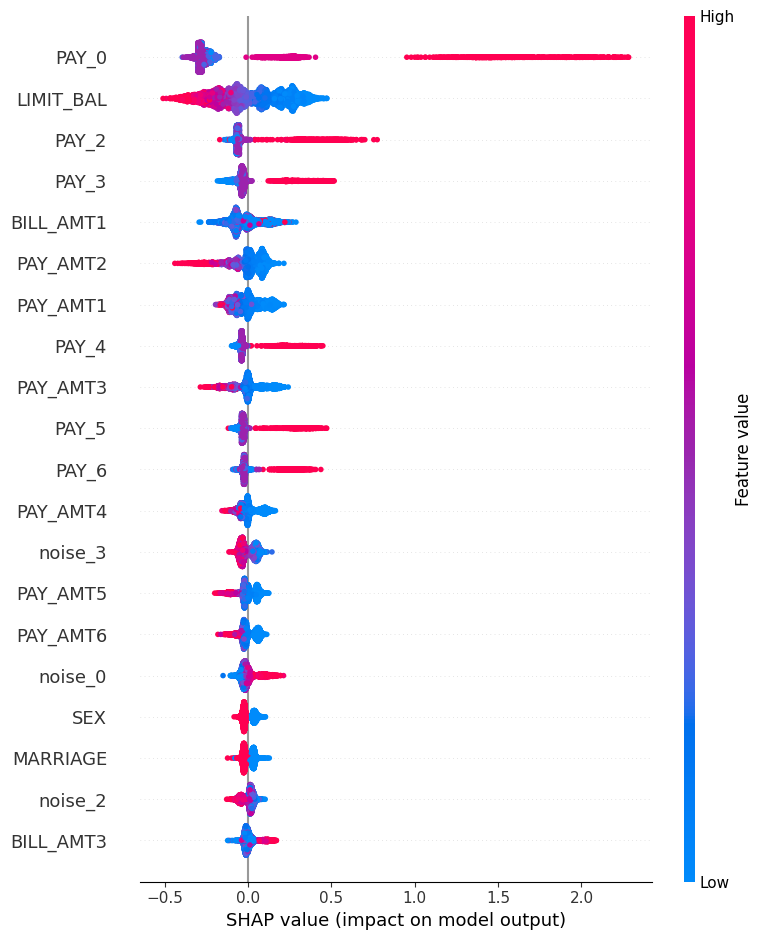

In [ ]:
plot_boxplot_importance(perm_imp_10_noise, X_val_10_noise)
shap.summary_plot(shap_values, X_test_10_noise, plot_type='bar')
shap.summary_plot(shap_values, X_test_10_noise, plot_type='dot')
shap.force_plot(explainer.expected_value, shap_values[0], X_test_10_noise.iloc[0])

In [ ]:
def find_feature_positions(df: pd.DataFrame, features: list) -> dict:
    positions = {}
    for feature in features:
        if feature in df['Feature'].values:
            position = df[df['Feature'] == feature].index[0]
            positions[feature] = position
    return positions

In [ ]:
perm_10_df = pd.DataFrame({
    'Feature': X_val_10_noise.columns,
    'Importance': perm_imp_10_noise.importances_mean
}).sort_values('Importance', ascending=False).reset_index(drop=True)
shap_10_df = pd.DataFrame({
    'Feature': X_test_10_noise.columns,
    'Importance': np.mean(np.abs(shap_values), axis=0)
}).sort_values('Importance', ascending=False).reset_index(drop=True)

noise_features = [f'noise_{i}' for i in range(10)]

noise_positions = {}
noise_positions['CatBoost'] = find_feature_positions(embedded_10_noise, noise_features)
noise_positions['Permutation'] = find_feature_positions(perm_10_df, noise_features)
noise_positions['SHAP'] = find_feature_positions(shap_10_df, noise_features)

positions_df = pd.DataFrame(noise_positions).sort_index()
positions_df

,CatBoost,Permutation,SHAP
noise_0,9,17,15
noise_1,15,19,30
noise_2,23,27,18
noise_3,19,24,12
noise_4,28,31,28
noise_5,30,29,32
noise_6,12,16,27
noise_7,11,26,24
noise_8,20,18,22
noise_9,26,32,25


SHAP - noise_6 попал на 13 место в рейтинге важности признаков, то есть может быть случайно выбран моделью как значимый и полезный для тренировки

Catboost - noise_8 на 18 месте; почти прошел половину признаков, но шанс того, что он нанесет какой-то ущерб качеству модели довольно мал

Permutation - наиболее влияющий шумовой признак noise_7 находится на 20 месте в рейтинге, так что перестановки справились с шумовыми признаками лучше всего в нашем случае


## Выполните отбор признаков с разными порогами 0%, 25%, 50%, 75% наименее важных признаков (удаляйте).

## Для каждого порога обучите модель и оцените ROC-AUC на тесте.

In [ ]:
thresholds = [0.0, 0.25, 0.5, 0.75]
results = []
for thr in thresholds:
    keep_features_num = int(len(perm_df) * (1 - thr))
    keep_features = perm_df['Feature'].head(keep_features_num).tolist()

    X_train_keeped = X_train[keep_features]
    X_val_keeped = X_val[keep_features]
    X_test_keeped = X_test[keep_features]

    cb_cls_keeped = get_catboost_model(
        X_train_keeped, y_train,
        X_val_keeped, y_val
    )
    roc_auc_keeped = get_auc(cb_cls_keeped, X_test_keeped, y_test)
    print_diff({f'Threshold {(thr * 100)}%': roc_auc_keeped}, all_models)
    results.append({
        'Threshold': thr,
        'features_deleted': len(perm_df['Feature'].tolist()) - keep_features_num,
        'ROC_AUC': roc_auc_keeped
    })


ROC AUC Score Threshold 0.0% -> 0.7719

Threshold 0.0% roc auc difference with other models:
Original -> -0.0032 (-0.4071%)
Noise Threshold -> 0.0168 (+2.2194%)
Without negative features -> -0.0056 (-0.7230%)


ROC AUC Score Threshold 25.0% -> 0.7737

Threshold 25.0% roc auc difference with other models:
Original -> -0.0014 (-0.1766%)
Noise Threshold -> 0.0185 (+2.4560%)
Without negative features -> -0.0038 (-0.4932%)
Threshold 0.0% -> 0.0018 (+0.2315%)


ROC AUC Score Threshold 50.0% -> 0.7739

Threshold 50.0% roc auc difference with other models:
Original -> -0.0012 (-0.1549%)
Noise Threshold -> 0.0187 (+2.4782%)
Without negative features -> -0.0037 (-0.4716%)
Threshold 0.0% -> 0.0020 (+0.2532%)
Threshold 25.0% -> 0.0002 (+0.0217%)


ROC AUC Score Threshold 75.0% -> 0.7654

Threshold 75.0% roc auc difference with other models:
Original -> -0.0097 (-1.2505%)
Noise Threshold -> 0.0102 (+1.3537%)
Without negative features -> -0.0122 (-1.5638%)
Threshold 0.0% -> -0.0065 (-0.8469%)
Thres

В качестве датафрейма признаков был взят перестановочный, так как на протяжении выполнения заданий, он показывал себя лучше всего. При удалении фичей модель немного улучшает качество - для неё достаточно признаков для построения связей, при этом уменьшается шум, но после порога в 50% удаленных фичей, roc auc резко начинает падать и показывает практически наихудший результат среди моделей - хуже только отсечка по случайному шуму. В этом случае модели уже начинает не хватать признаков для полноценного качественного обучения.

In [ ]:
results_df = pd.DataFrame(results)
results_df

,Threshold,features_deleted,ROC_AUC
0,0.00,0,0.771911
1,0.25,6,0.773698
2,0.50,12,0.773866
3,0.75,18,0.765374


## Постройте график зависимости ROC-AUC от количества удаленных признаков.

In [ ]:
def plot_auc_del_features(results_df: pd.DataFrame, original_auc: float) -> None:
    plt.figure(figsize=(10, 6))
    plt.plot(results_df['features_deleted'], results_df['ROC_AUC'], marker='o', label='ROC-AUC')
    plt.axhline(results_df[results_df['features_deleted'] == 0]['ROC_AUC'].values[0], linestyle='--', color='red', alpha=0.5, label='До удаления признаков')
    plt.title('Зависимость ROC_AUC от количества удаленных признаков')
    plt.xlabel('Количество удаленных признаков')
    plt.ylabel('ROC-AUC')
    plt.xticks(results_df['features_deleted'])
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

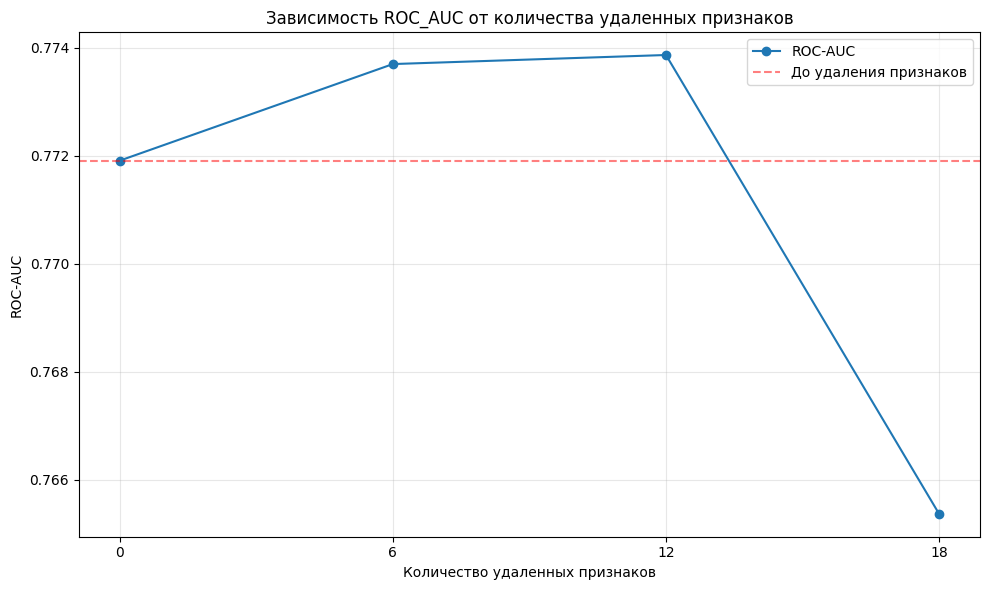

In [ ]:
plot_auc_del_features(results_df, roc_auc_original)

## Проанализируйте, как изменяется качество модели при удалении разных долей признаков.

In [ ]:
results_df

,Threshold,features_deleted,ROC_AUC
0,0.00,0,0.771911
1,0.25,6,0.773698
2,0.50,12,0.773866
3,0.75,18,0.765374


В качестве датафрейма признаков был взят перестановочный, так как на протяжении выполнения заданий, он показывал себя лучше всего. При удалении фичей модель немного улучшает качество - для неё достаточно признаков для построения связей, при этом уменьшается шум, но после порога в 50% удаленных фичей, roc auc резко начинает падать и показывает практически наихудший результат среди моделей - хуже только отсечка по случайному шуму. В этом случае модели уже начинает не хватать признаков для полноценного качественного обучения.